In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier, XGBRegressor

import shap
import joblib

sns.set_style("whitegrid")

In [2]:
CONFIG = {
    "data_path": "data/parkinsons_voice.csv",
    "output_dir": "voice_outputs",
    "test_size": 0.2,
    "val_size": 0.1,
    "random_state": 42,
    "num_features": 15
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)

In [4]:
df = pd.read_csv(CONFIG["data_path"])

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (195, 24)


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

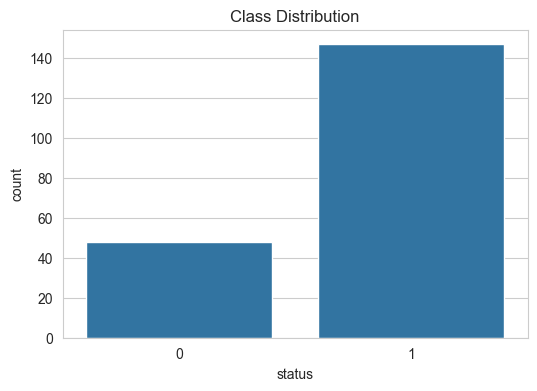

In [5]:
print(df.info())
print(df.describe())

plt.figure(figsize=(6,4))
sns.countplot(x="status", data=df)
plt.title("Class Distribution")
plt.savefig(f"{CONFIG['output_dir']}/class_distribution.png")
plt.show()

In [6]:
df = df.drop(columns=["name"], errors="ignore")

df = df.fillna(df.median())

print("Missing Values:", df.isnull().sum().sum())

Missing Values: 0


In [8]:
# status = 1 → Parkinson
# status = 0 → Healthy

X = df.drop(columns=["status"])
y = df["status"]

feature_names = X.columns.tolist()

print("Total features:", len(feature_names))


Total features: 22


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=CONFIG["test_size"],
    stratify=y,
    random_state=CONFIG["random_state"]
)

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
selector = SelectKBest(score_func=f_classif, k=CONFIG["num_features"])

X_train_sel = selector.fit_transform(X_train_scaled, y_train)
X_test_sel = selector.transform(X_test_scaled)

selected_features = np.array(feature_names)[selector.get_support()]

print("Selected Features:")
print(selected_features)

Selected Features:
['MDVP:Fo(Hz)' 'MDVP:Flo(Hz)' 'MDVP:Jitter(Abs)' 'MDVP:Shimmer'
 'MDVP:Shimmer(dB)' 'Shimmer:APQ3' 'Shimmer:APQ5' 'MDVP:APQ' 'Shimmer:DDA'
 'HNR' 'RPDE' 'spread1' 'spread2' 'D2' 'PPE']


In [12]:
models = {
    
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_split=5,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=400,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ),

    "MLP": MLPClassifier(
        hidden_layer_sizes=(128,64),
        activation="relu",
        alpha=0.0005,
        max_iter=800,
        random_state=42
    )
}

In [13]:
results = {}

for name, model in models.items():
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    scores = cross_val_score(
        model,
        X_train_sel,
        y_train,
        cv=cv,
        scoring="f1"
    )
    
    results[name] = scores.mean()
    
    print(name, "F1 CV Score:", scores.mean())

RandomForest F1 CV Score: 0.9330130718954248
XGBoost F1 CV Score: 0.9380775799681574
MLP F1 CV Score: 0.9317144619179771


In [14]:
trained_models = {}

for name, model in models.items():
    
    model.fit(X_train_sel, y_train)
    trained_models[name] = model

In [15]:
def evaluate_model(model, X_test, y_test, name):

    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    roc = roc_auc_score(y_test, probs)

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("ROC-AUC:", roc)

    print(classification_report(y_test, preds))

    return preds, probs

In [16]:
evaluation = {}

for name, model in trained_models.items():

    preds, probs = evaluate_model(model, X_test_sel, y_test, name)

    evaluation[name] = (preds, probs)


RandomForest
Accuracy: 0.8974358974358975
Precision: 0.9310344827586207
Recall: 0.9310344827586207
F1: 0.9310344827586207
ROC-AUC: 0.9482758620689655
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        10
           1       0.93      0.93      0.93        29

    accuracy                           0.90        39
   macro avg       0.87      0.87      0.87        39
weighted avg       0.90      0.90      0.90        39


XGBoost
Accuracy: 0.9230769230769231
Precision: 0.9642857142857143
Recall: 0.9310344827586207
F1: 0.9473684210526315
ROC-AUC: 0.9655172413793104
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.96      0.93      0.95        29

    accuracy                           0.92        39
   macro avg       0.89      0.92      0.90        39
weighted avg       0.93      0.92      0.92        39


MLP
Accuracy: 0.9230769230769231
Precision: 0.96

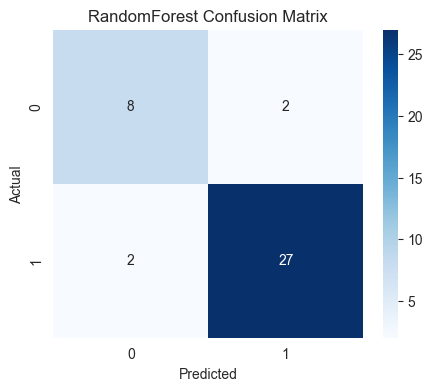

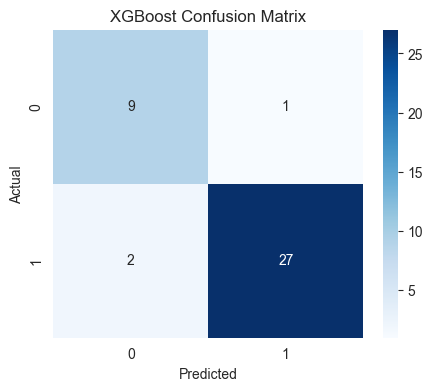

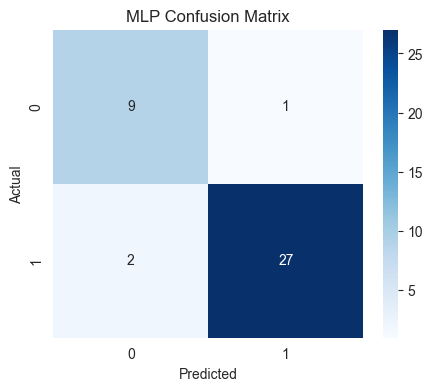

In [17]:
for name, (preds, probs) in evaluation.items():

    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.savefig(f"{CONFIG['output_dir']}/{name}_confusion_matrix.png")
    plt.show()

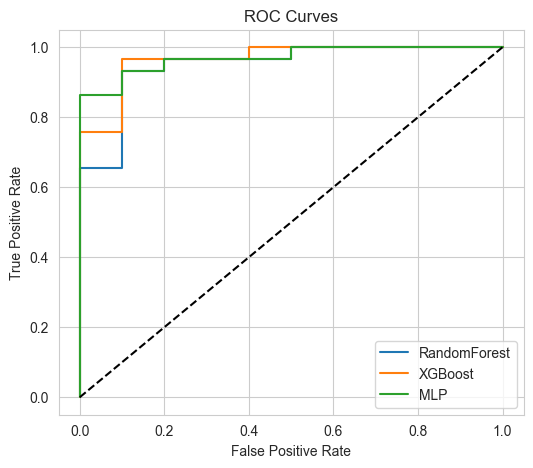

In [18]:
plt.figure(figsize=(6,5))

for name, (preds, probs) in evaluation.items():

    fpr, tpr, _ = roc_curve(y_test, probs)

    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curves")

plt.legend()

plt.savefig(f"{CONFIG['output_dir']}/roc_curves.png")

plt.show()

In [19]:
best_model_name = max(results, key=results.get)

best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: XGBoost


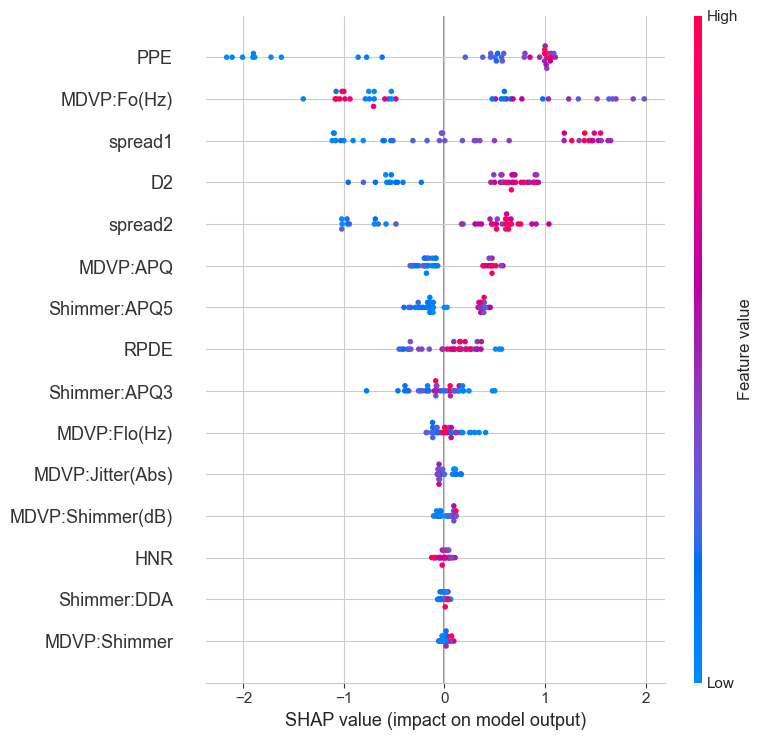

In [20]:
explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test_sel)

plt.figure()
shap.summary_plot(
    shap_values,
    X_test_sel,
    feature_names=selected_features,
    show=False
)

plt.savefig(f"{CONFIG['output_dir']}/shap_summary.png")
plt.show()

In [21]:
joblib.dump(best_model, f"{CONFIG['output_dir']}/voice_model.pkl")

joblib.dump(scaler, f"{CONFIG['output_dir']}/scaler.pkl")

joblib.dump(selector, f"{CONFIG['output_dir']}/feature_selector.pkl")

joblib.dump(selected_features.tolist(),
            f"{CONFIG['output_dir']}/feature_names.pkl")

print("Models saved successfully")

Models saved successfully
